# Example deconvolution

In this notebook, we show a small locus is deconvolved for both the chromatin and for transcripts within the window.

In [29]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
from src.config import load_default_chrom_configs
from src.combined_chromatin_model import CombinedChromatinModel

# Load the chromatin configuration objects containing
# information on the CLOCCS parameters, the timing, and the predetermined alpha
# parameter values
config1, config2 = load_default_chrom_configs()
print("Here is an example of the config parameters and their values:", config1.params_dic)
print("Here are the experimental times collected for a replicate:", config1.timepoints)


Here is an example of the config parameters and their values: {'mu0': -26.7901, 'delta': 8.1805, 'sigma0': 10.9885, 'sigmav': 0.1424, 'lambda': 68.1914, 'gamma1': 0.0041, 'gamma2': 0.2547, 'halted': 0.2245, 'alpha': 34, 'num_g1_indices': 62}
Here are the experimental times collected for a replicate: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]


In [78]:
# Load the chromatin model that will perform the deconvolution
combined_model = CombinedChromatinModel(config1=config1, config2=config2)

# Then load the specific window that we are interested in deconvolving
chrom = 16
mnase_span = (774800, 776000)
combined_model.load_mnase_span(chrom, mnase_span)

Loading chromosome reads: 16
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 1199) to (16, 26, 120)
Loading chromosome reads: 16
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (15, 251, 1199) to (15, 26, 120)


In [79]:
# Setup the deconvolution with sample parameters and deconvolve
combined_model.setup_deconv_model(copy_correct=False)
combined_model.deconvolve(gamma=0.06, kappa=0.01)

Loading copy correction N, Fr, B from output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr
0/3120 - 00:00:00.001
500/3120 - 00:00:07.242
1000/3120 - 00:01:17.570
1500/3120 - 00:02:40.156
2000/3120 - 00:04:05.083
2500/3120 - 00:05:28.981
3000/3120 - 00:06:50.643
Completed - 00:07:00.612


In [112]:
# Deconvolve the gene expression
from src.utils import mkdir_safe

from pipeline.CombinedDeconvolveGeneExpressionRunner import CombinedDeconvolveGeneExpressionRunner

example_output_dir = 'output/example'
mkdir_safe(example_output_dir)
expression_runner = CombinedDeconvolveGeneExpressionRunner(example_output_dir)
_ = expression_runner.deconvolve_gene_optimal_gamma('CLB5', kappa=0.01)
clb5_f = expression_runner.expression_find_gamma.retrieve_solution()

Creating directory: output/example...Directory exists. Skipping.


Text(0.5, 1.07, 'Raw $\\it{CLB5}$ expression')

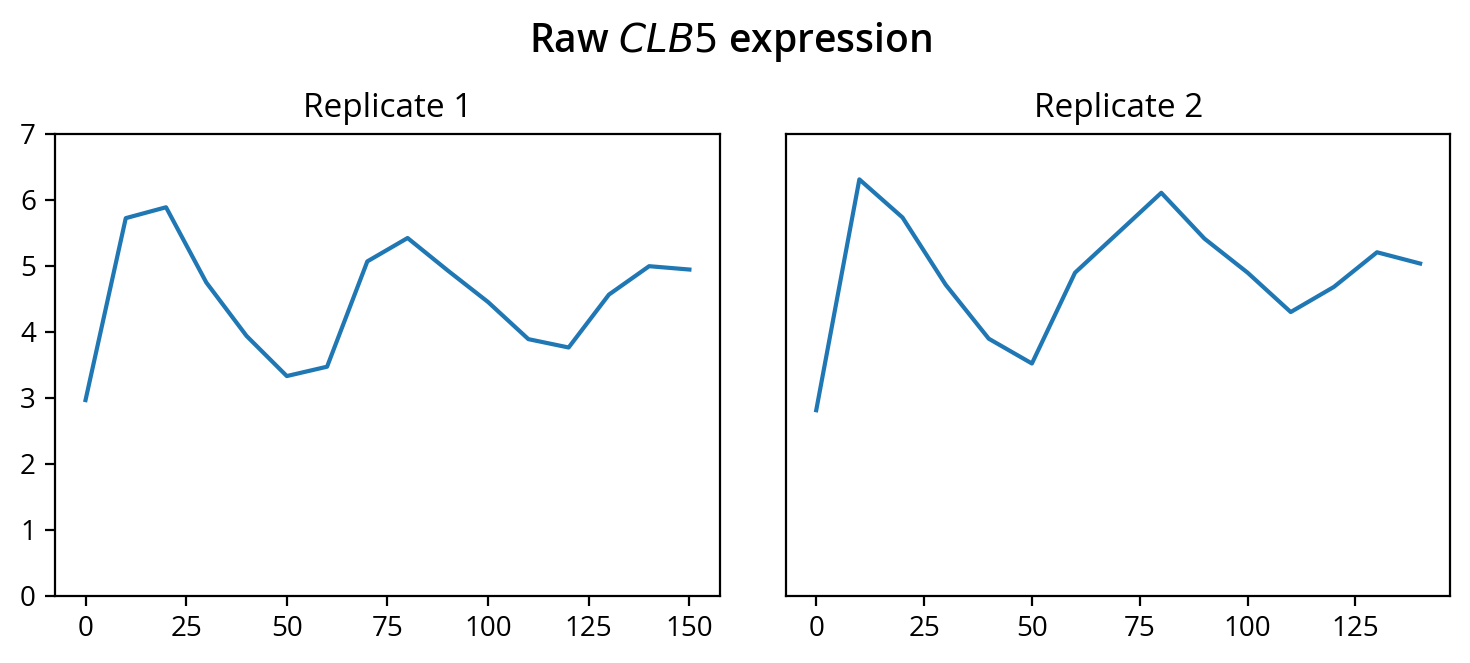

In [160]:
# Plot the raw expression for comparison

combined_g = expression_runner.expression_find_gamma.deconvolution_solver.g
expression_tps_rep1 = expression_runner.config1.timepoints
expression_tps_rep2 = expression_runner.config2.timepoints
rep1_g_raw = combined_g[:len(expression_tps_rep1)]
rep2_g_raw = combined_g[len(expression_tps_rep1):]

plt.figure(figsize=(9, 3))
plt.subplot(1, 2, 1)
plt.plot(expression_tps_rep1, rep1_g_raw)
plt.title("Replicate 1")
plt.ylim(0, 7)

plt.subplot(1, 2, 2)
plt.plot(expression_tps_rep2, rep2_g_raw)
plt.title("Replicate 2")
plt.ylim(0, 7)
plt.yticks([])
plt.subplots_adjust(wspace=0.1)

plt.suptitle("Raw $\\it{CLB5}$ expression", fontweight='demi', fontsize=14, y=1.07)


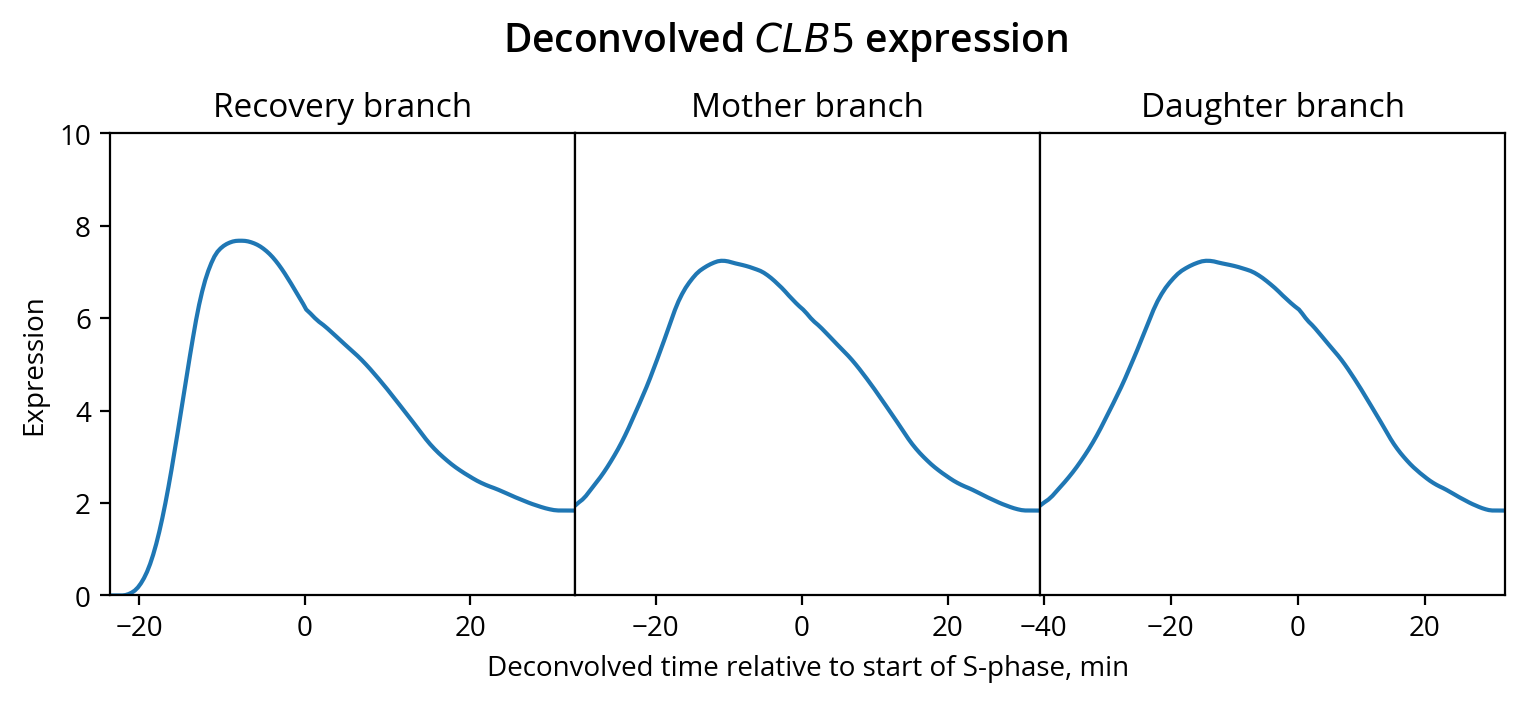

In [144]:
from src.config import get_average_timepoints_for_branch

# Retrieve the average timepoints (of replicates 1 and 2) for each branch
# for plotting
i_tps = get_average_timepoints_for_branch(config1, config2, 'i')
t_tps = get_average_timepoints_for_branch(config1, config2, 't')
b_tps = get_average_timepoints_for_branch(config1, config2, 'b')

# Plot the deconvolved branches for the expression
plt.figure(figsize=(9, 3))
plt.subplot(1, 3, 1)
plt.plot(i_tps, clb5_f[config1.i_indices()])
plt.ylim(0, 10)
plt.xlim(i_tps[0], i_tps[-1])
plt.ylabel("Expression")
plt.title("Recovery branch")

plt.subplot(1, 3, 2)
plt.plot(t_tps, clb5_f[config1.t_indices()])
plt.ylim(0, 10)
plt.xlim(t_tps[0], t_tps[-1])
plt.yticks([])
plt.xlabel("Deconvolved time relative to start of S-phase, min")
plt.title("Mother branch")

plt.subplot(1, 3, 3)
plt.plot(b_tps, clb5_f[config1.b_indices()])
plt.ylim(0, 10)
plt.xlim(b_tps[0], b_tps[-1])
plt.yticks([])
plt.title("Daughter branch")

plt.suptitle("Deconvolved $\\it{CLB5}$ expression", fontweight='demi', fontsize=14, y=1.07)
plt.subplots_adjust(wspace=0)


In [ ]:
from src.expression_chromatin_plots import DeconvolutionChromatinExpressionPlotter
from src.ChromatinRNALocusPlotter import SingleBranchChromatinPlotter
from src.rna_pileup_plotter import RNASeqPileupPlotter
from pipeline.transcription_processor import ExpressionAnalysisProcessor
from src.deconvolved_tpm_plotter import DeconvolvedTPMPlotter

# For locus plotting
expression_processor = ExpressionAnalysisProcessor('output/draft4_run/')
expression_processor.setup_data_loaders()
expression_processor.load_deconvolved_expression()
tpm_plotter = DeconvolvedTPMPlotter(expression_processor.expression_data,
    expression_processor.all_transcripts_set)
rna_plotter = RNASeqPileupPlotter('output/draft4_run/')

Loaded 9663 transcripts
  5774 genic transcripts
  3889 non-genic transcripts
Loading deconvolved gene expression data...
Loading deconvolved expression files, n= 9663
Loaded expression data: 9663 transcripts, 257 timepoints
Creating directory: output/draft4_run//rna_seq_intermediate...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/reads...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/pileups...Directory exists. Skipping.
Initialized RNASeqIntermediateManager for chromosome 16
Intermediate directory: output/draft4_run//rna_seq_intermediate
Loaded pileups from watson_rna_seq_pileup_rep1_chr16.h5, crick_rna_seq_pileup_rep1_chr16.h5
Shape: (16, 948066) (timepoints x positions)
Loaded pileups from watson_rna_seq_pileup_rep2_chr16.h5, crick_rna_seq_pileup_rep2_chr16.h5
Shape: (14, 948066) (timepoints x positions)


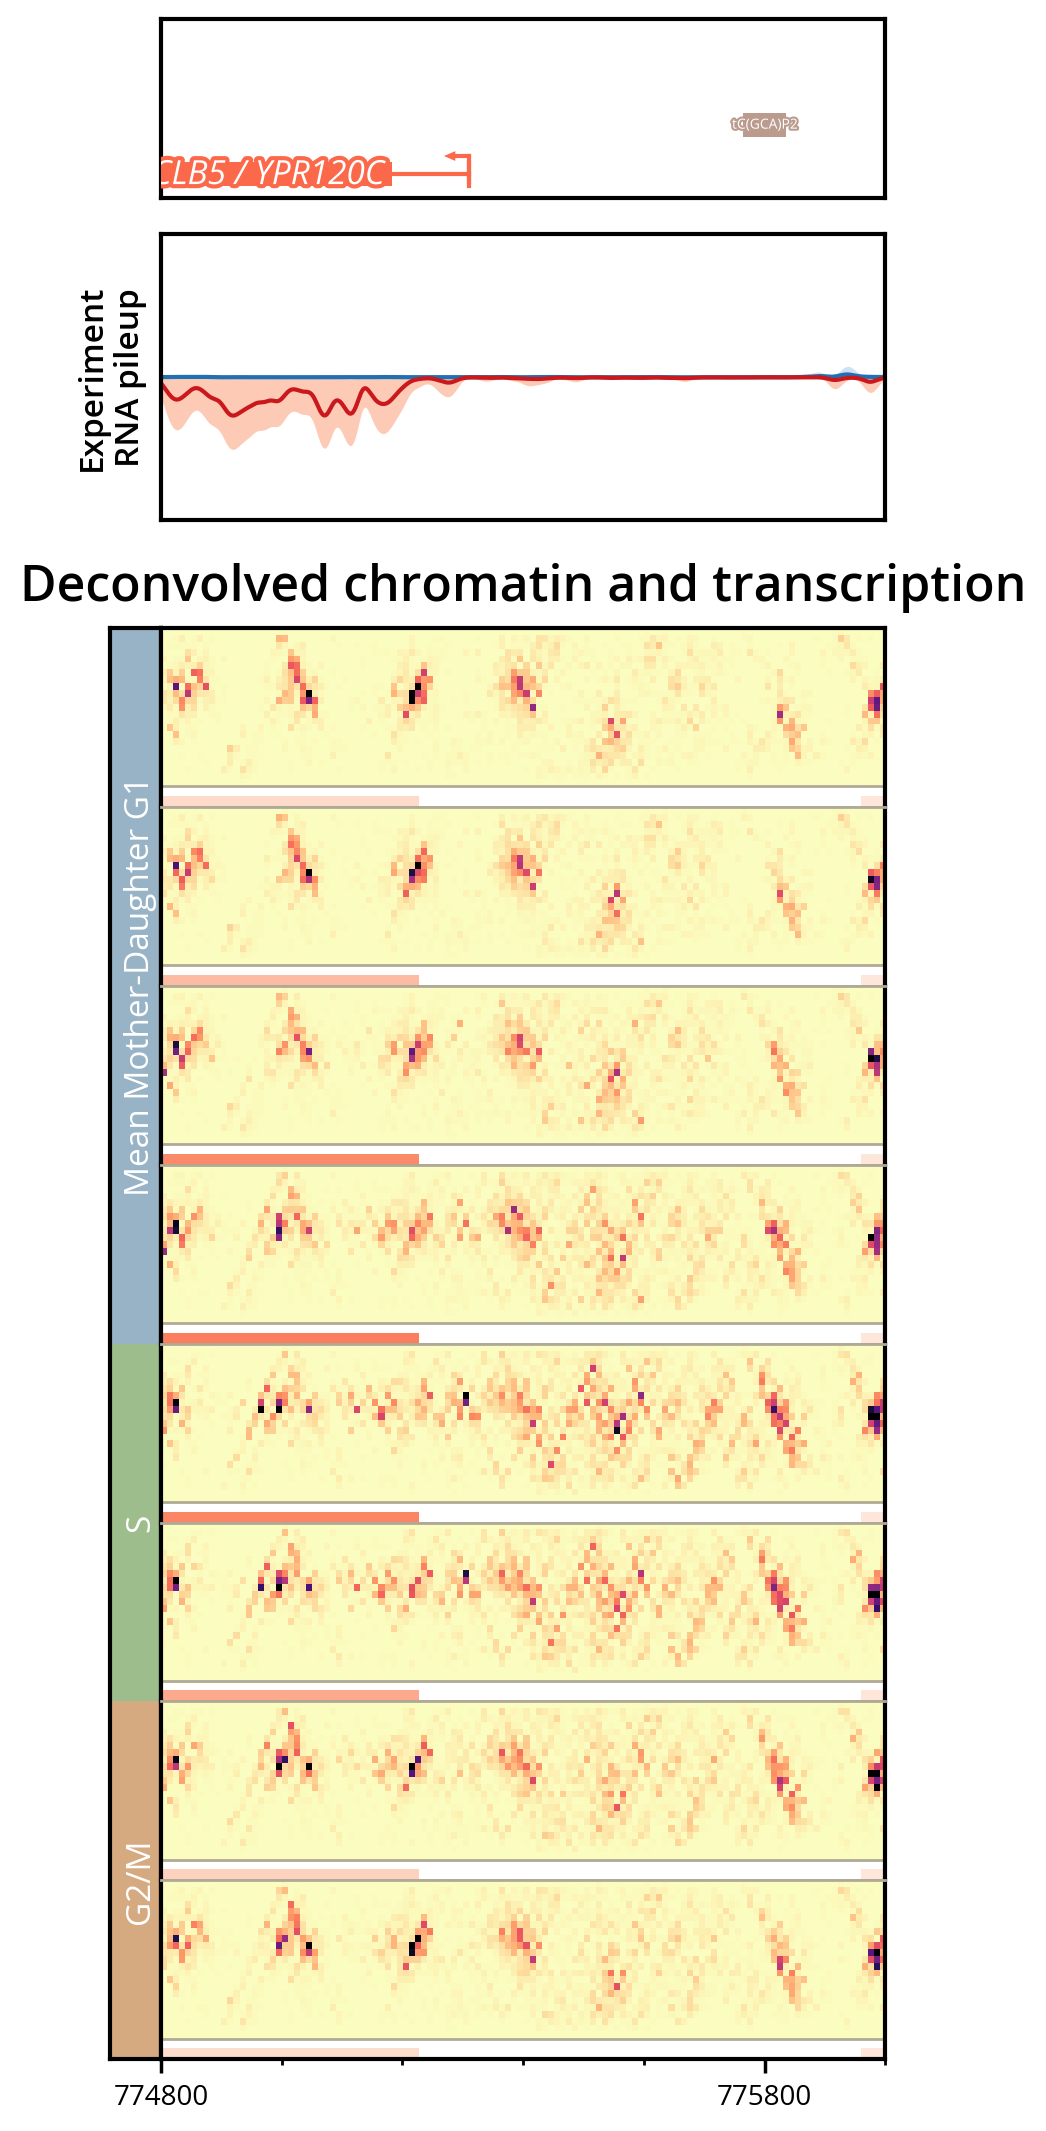

In [88]:
plotter = SingleBranchChromatinPlotter(
    outdir=None,
    config1=config1,
    figsize=(5, 12),
    branch_type='mean_mother_daughter',
    title='',
    rna_plotter=rna_plotter,
    deconvolved_tpm_plotter=tpm_plotter,
    plot_index_labels=False
)

img_shape = combined_model.chrom1_model.image_shape
plotter.set_chrom_span(chrom, mnase_span)
plotter.set_chromatin_data(combined_model.F.reshape(-1, img_shape[0], img_shape[1]))

fig = plotter.plot()


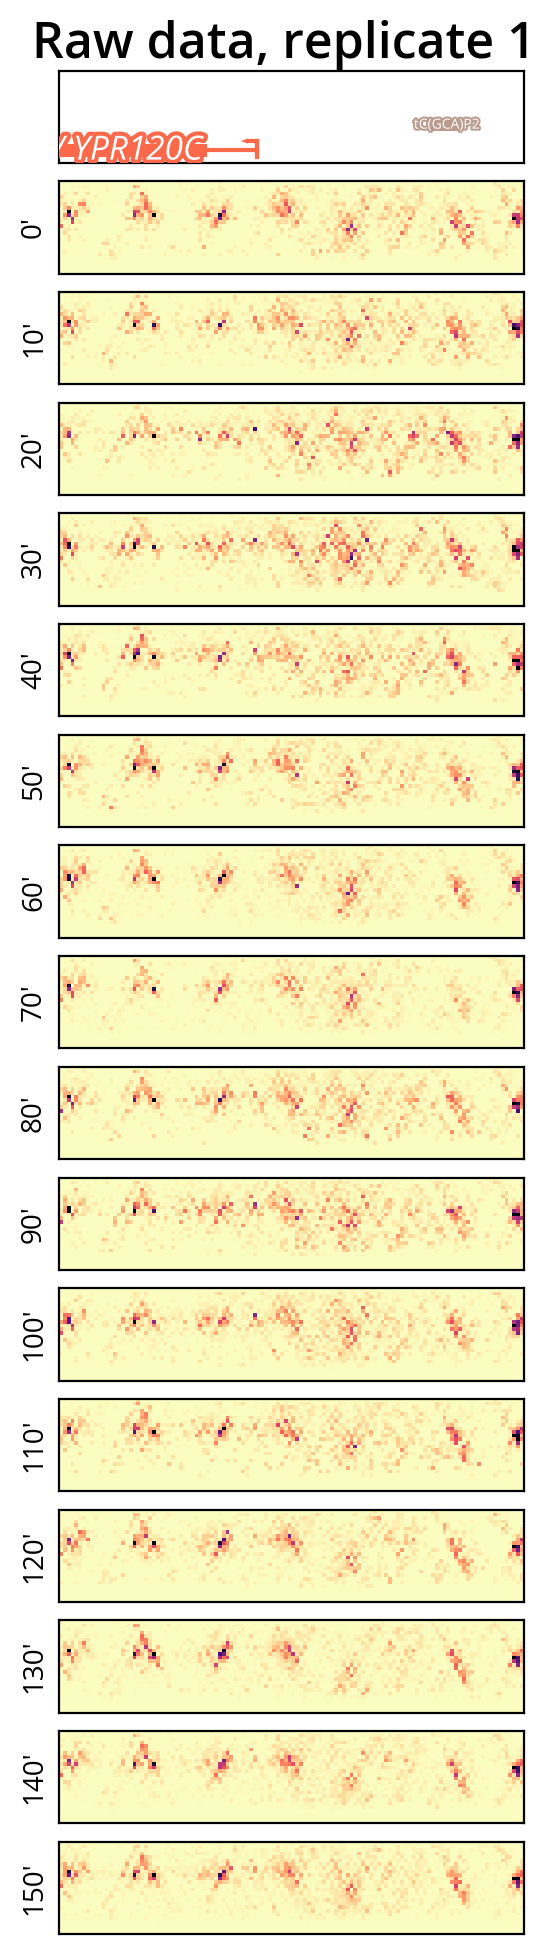

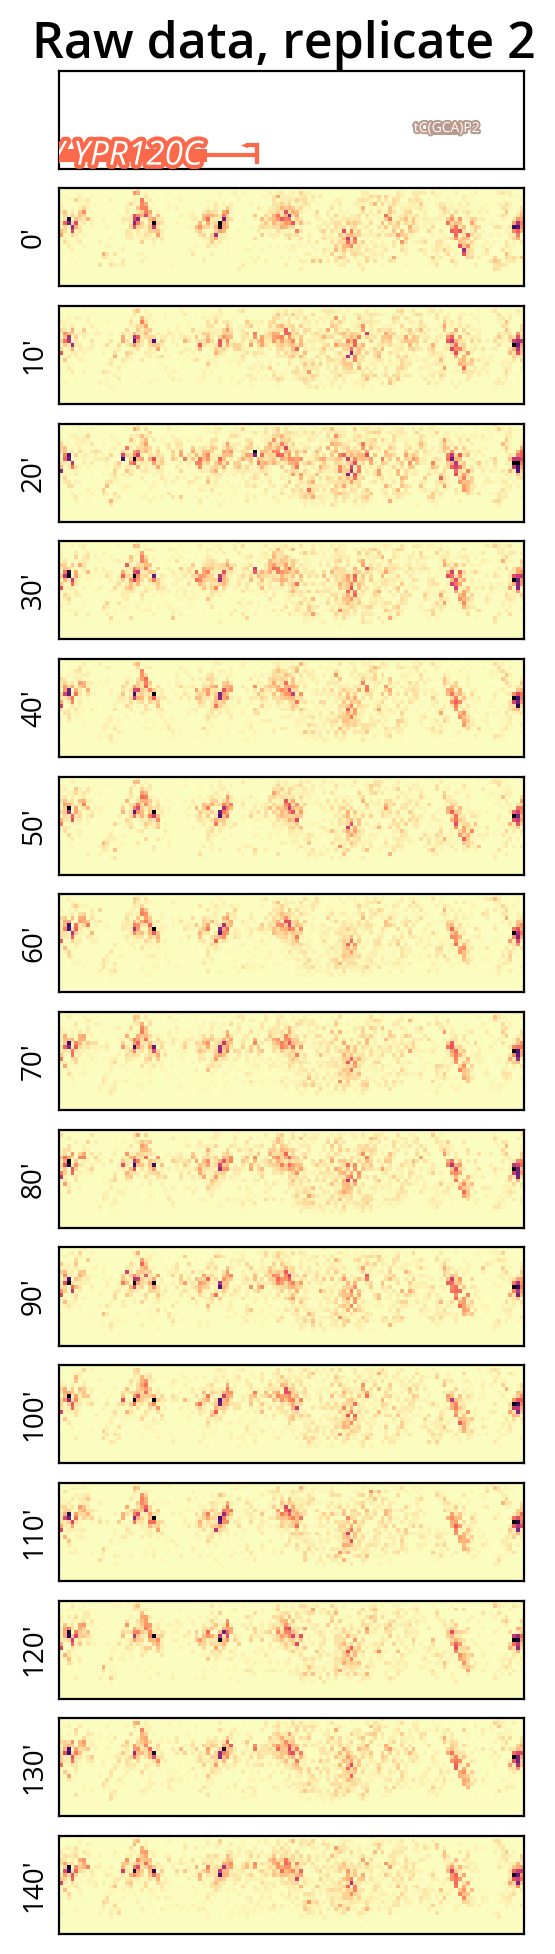

In [85]:
# And we can compare to the raw chromatin data for ach replicate
fig = combined_model.chrom1_model.plot_raw_data(figsize=(3, 11))
fig = combined_model.chrom2_model.plot_raw_data(figsize=(3, 11))